In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
# Put in the pyodine path on your machine here!
pyodine_path = '/home/skleiman/pyodineAPF'

sys.path.append(pyodine_path)

import pyodine
import pyodine_create_templates     # <- the template creation routines
import utilities_apf as utilities


In [2]:
Pars = utilities.pyodine_parameters.Template_Parameters()
Pars.deconvolution_pars


{'osample_temp': 10,
 'jansson_niter': 1200,
 'jansson_zerolevel': 0.0,
 'jansson_contlevel': 1.02,
 'jansson_conver': 0.2,
 'jansson_chi_change': 1e-06,
 'lsf_conv_width': 6.0}

In [3]:
#10 01 for O star, HR files

# O-star observations to use for the mod?elling
ostar_dir   = "/data/APF_reductions/HD203030/20241001/PyPyPiOUT/"
ostar_files = glob.glob(ostar_dir+"PyPyPied_In_HR7906*")
ostar_files2 = glob.glob(ostar_dir+"PyPyPied_In_HR8781*")
for name in ostar_files2:
    ostar_files.append(name)
#ostar_files = ostar_files[0:2]
print(ostar_files)

# HD 203030 files
# Stellar observations to use for the deconvolution
temp_dir   = "/data/APF_reductions/HD203030/20241001/PyPyPiOUT/"
temp_files =  glob.glob(ostar_dir+"PyPyPied_Out_HD*")
temp_files.sort()
print(temp_files)

# Output pathname for the summed, normalized template observations
obs_sum_outname = os.path.join("/data/APF_recuctions/HD203030/20241001/summed_HD203030.fits")

# Output pathname for the template
temp_outname = os.path.join("/data/APF_recuctions/HD203030/20241001/template_HD203030.fits")

# Output directory for plots and pathnames for modelling results
os.makedirs("/data/APF_recuctions/HD203030/20241001/pyodine_outs/", exist_ok=True)
plot_dir  = "/data/APF_recuctions/HD203030/20241001/pyodine_outs/"
res_files = [os.path.join(plot_dir, 'HD203030_2024_10_01_res0.h5'),
             os.path.join(plot_dir, 'HD203030_2024_10_01_res1.pkl')]

# Log files
error_file = os.path.join(plot_dir, 'error.log')
info_file  = os.path.join(plot_dir, 'info.log')

['/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13707.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13706.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13715.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13716.fits']
['/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13708.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13709.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13710.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13711.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13712.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13713.fits', '/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD20303


Branch: main
Hash: eec592a
---------------------------
Aiming to create template: /data/APF_recuctions/HD203030/20241001/template_HD203030.fits


APF IN USE
APF IN USE
APF IN USE
APF IN USE

Hot star observations (4):
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13707.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR7906_20241001_13706.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13715.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_In_HR8781_20241001_13716.fits
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE
APF IN USE

Stellar template observations (7):
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13708.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13709.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13710.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13711.fits
/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13712.fits
/data/AP

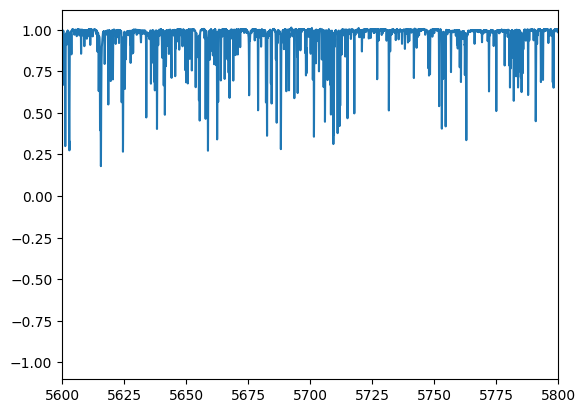

In [4]:
pyodine_create_templates.create_template(utilities, Pars, ostar_files, temp_files, 
                                         temp_outname, plot_dir=plot_dir, res_files=res_files, 
                                         obs_sum_outname=obs_sum_outname, error_log=error_file, 
                                         info_log=info_file)

In [5]:
fit_results_1 = pyodine.fitters.results_io.load_results(res_files[1], filetype='dill')

# Also construct the original chunks array of the O/B-star observations
chunks = pyodine.components.ChunkArray()
for r in fit_results_1:
    chunks.append(r.chunk)

In [ ]:
print('Number of chunks/fit results:', len(fit_results_1))
print('\nObject structure of each fit result:')
print(fit_results_1[0].__dict__)

In [ ]:
chunks, fit_results_0 = pyodine.fitters.results_io.restore_results_object(
    utilities, res_files[0])

In [ ]:
chunk_ind = 26

pyodine.plot_lib.plot_chunkmodel(fit_results_1, chunks, chunk_ind, template=False, 
                                 show_plot=True)


In [ ]:
residuals = pyodine.plot_lib.plot_residual_hist(fit_results_1, title='Residuals histogram', 
                                                show_plot=True)

In [ ]:
pyodine.plot_lib.plot_chunk_scatter(scatter=residuals, ylabel='Chunk residuals [%]', 
                                    title='Chunk residuals', show_plot=True)

In [ ]:
# The LSF model, oversampling and convolution width used
lsf_model      = fit_results_1[0].model.lsf_model
osample_factor = fit_results_1[0].model.osample_factor
conv_width     = fit_results_1[0].model.conv_width

# Generate the pixel vector to evaluate the LSF over
lsf_x = lsf_model.generate_x(osample_factor=osample_factor, conv_width=conv_width)

# Now loop over all chunks, evaluate the LSFs and append them to a list
lsfs = []
for i in range(len(fit_results_1)):
    lsf_pars = fit_results_1[i].params.filter('lsf')
    lsfs.append(lsf_model.eval(lsf_x, lsf_pars))

# Finally plot a grid of 3x3 LSFs
pyodine.plot_lib.plot_lsfs_grid(lsfs, chunks, x_lsf=lsf_x, x_nr=3, y_nr=3, 
                                alpha=0.7, xlim=(-4,4), show_plot=True)

In [ ]:
# The best-fit wavelength slopes for all chunks
wave_slopes_model = [r.params['wave_slope'] for r in fit_results_1]
# The estimated dispersion for all chunks (from the original spectrum)
wave_slopes_data = [(ch.wave[-1]-ch.wave[0])/len(ch) for ch in chunks]

pyodine.plot_lib.plot_chunk_scatter(scatter=[wave_slopes_model,wave_slopes_data], 
                                    scatter_fmt='.', scatter_label=['model', 'data'], 
                                    ylabel=r'wave_slope [$\AA$/pix]', show_plot=True)

In [ ]:
# Chunk index
chunk_ind = 26

pyodine.plot_lib.plot_chunkmodel(fit_results_0, chunks, chunk_ind, template=False, 
                                 show_plot=True)

In [ ]:
template = pyodine.template.base.StellarTemplate_Chunked(temp_outname)

print('The deconvolved template object:\n', template)
print('\nThe first chunk of the template:\n', template[0])

In [ ]:
from astropy.io import fits

with fits.open(obs_sum_outname) as hdu:
    temp_obs_flux = hdu[0].data[0]      # <- ind 0: normalized flux
    temp_obs_wave = hdu[0].data[2]      # <- ind 2: wavelengths

In [ ]:
# Chunk index
chunk_ind = 26

# The wavelength range covered by this chunk
wave_range = [template[chunk_ind].wave[0], template[chunk_ind].wave[-1]]

# Get the (order,pixel)-indices of the 
# summed observation covering this range
ind = np.where(np.logical_and(temp_obs_wave > wave_range[0], 
                              temp_obs_wave < wave_range[1]))

# And plot
fig = plt.figure(figsize=(10,6))
plt.plot(template[chunk_ind].wave, template[chunk_ind].flux, 
         alpha=0.7, label='Deconvolved template')
plt.plot(temp_obs_wave[ind], temp_obs_flux[ind], 
         alpha=0.7, label='Summed template obs.')
plt.legend()
plt.xlabel(r'Wavelength [$\AA$]')
plt.title('{}, chunk {}'.format(template.starname, chunk_ind))
plt.show()

In [ ]:
from pyodine import template as temp

In [ ]:
temp.normalize.top

In [ ]:
import astropy.io.fits as fits

In [ ]:
h = fits.open("/data/APF_reductions/HD203030/20240804/Science/spec1d_20240804_16143-HD203030_apf_20240805T120752.940.fits")
header = h[1].header
order = header["HIERARCH ECH_ORDER"]
print(order)
d = h[1].data
raw_flux = d["BOX_COUNTS"]
wavelengths = d["BOX_WAVE"]

In [ ]:
h[0].header

In [ ]:
raw_flux

In [ ]:
blaze_func = temp.normalize.top(raw_flux)

In [ ]:
type(blaze_func)

In [ ]:
fig = plt.figure(figsize=(20,10))
plt.plot(wavelengths,raw_flux,color = 'dodgerblue', label = 'Raw Flux')
plt.title("Fitting the Blaze Function")
plt.xlabel("Wavelength ($\AA$)")
plt.ylabel("Counts")
plt.plot(wavelengths,blaze_func,color = 'firebrick', label = 'Blaze Function')
plt.legend()

In [ ]:
h = fits.open("/data/APF_reductions/HD203030/20240804/Science/spec1d_20240804_16143-HD203030_apf_20240805T120752.940.fits")
for i in np.arange(1,56):
    d = h[i].data
    header = h[i].header
    order = header["HIERARCH ECH_ORDER"]
    wl = d["BOX_WAVE"]
    flux = d["BOX_COUNTS"]
    blaze = temp.normalize.top(flux,deg=5,max_iter=100)
    if i ==1:
        blaze_funcs = blaze
    if i > 1:
        blaze_funcs = np.vstack((blaze_funcs, blaze))

blaze_hdu = fits.ImageHDU(data = blaze_funcs)


    #plt.figure(figsize=(12,6))
    #plt.plot(wl,flux,color = 'dodgerblue', label = 'Raw Flux')
    #plt.title("Fitting the Blaze Function, Order: "+str(order))
    #plt.xlabel("Wavelength ($\AA$)")
    #plt.ylabel("Counts")
    #plt.plot(wl,blaze,color = 'firebrick', label = 'Blaze Function')
    #plt.legend()
    #add new fits rather than changing old -- something like name_+blaze.fits
out_file = "/data/APF_reductions/HD203030/20240804/Science/spec1d_20240804_16143-HD203030_apf_20240805T120752.940.fits"
with fits.open(out_file) as hdul:
    name = hdul[0].header["FILENAME"]
    dir_path = os.path.dirname(out_file)
    out_path = os.path.join(dir_path,"PyPyPied_"+name)
    hdul.append(blaze_hdu)
    hdul.writeto(out_path, overwrite=True)
        

In [ ]:
x= np.array([1,2,3,4,5])
y= np.array([])

In [ ]:
with fits.open('/data/APF_reductions/HD203030/20240804/Science/spec1d_20240804_16143-HD203030_apf_20240805T120752.940.fits') as hdul:
    # Create some example data for the new HDU
    new_data = np.random.rand(100, 100)
    print(new_data)
    # Create a new ImageHDU (assuming you're adding an image)
    new_hdu = fits.ImageHDU(data=new_data)

    # Add some header keywords to the new HDU
    new_hdu.header['TELESCOP'] = 'New Telescope'
    new_hdu.header['DATE'] = '2025-07-10'

    # Append the new HDU to the existing HDUList
    hdul.append(new_hdu)
    x = hdul[57].data
    

In [ ]:
x[2]

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
c = np.array([7, 8, 9])
b = np.append(a,[b])

In [ ]:
b = np.append(b,[c],axis=0)

In [ ]:
b

In [ ]:
fits.TableHDU?


In [ ]:
a = fits.open("/data/APF_reductions/HD203030/20240804/Science/PyPyPied_20240804_16143.fits")

In [ ]:
blzs = a[57].data

In [ ]:
blzs[55]

In [ ]:
from astroquery.simbad import Simbad
Simbad = Simbad()

In [ ]:
Simbad.add_votable_fields('pmra', 'pmdec')
Simbad.query_object("HD203030")

In [ ]:
Simbad.add_votable_fields('rv')

Simbad.get_votable_fields()



In [ ]:
Simbad.list_votable_fields()[0:20]

In [ ]:
Simbad.list_votable_fields()[20:40]


In [ ]:
Simbad.list_votable_fields()[40:60]


In [ ]:
Simbad.list_votable_fields()[60:80]


In [ ]:
Simbad.list_votable_fields()[80:100]

In [ ]:
import astropy.io.fits as fits

data = fits.open('/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_HD203030_20241001_13712.fits')

In [ ]:
data[56].data

In [ ]:
from jdcal import gcal2jd
import numpy as np

In [ ]:
gcal2jd(2024,10,1)

In [ ]:
date = data[0].header["THEMIDPT"]

In [ ]:
date_pri = date[0:10]

In [ ]:
x_pri=date_pri.split('-')

In [ ]:
for i in np.arange(0,len(x_pri)):
    x_pri[i] = float(x_pri[i])

In [ ]:
x_pri

In [ ]:
date_sec = date[11:]
date_sec
x_sec = date_sec.split(':')
for i in np.arange(0,len(x_sec)):
    x_sec[i]=float(x_sec[i])

In [ ]:
x_sec

In [ ]:
sum(gcal2jd(x_pri[0],x_pri[1],x_pri[2]))+(x_sec[0]+x_sec[1]/60+x_sec[2]/3600)/24

In [ ]:
import astropy.io.fits as fits

data = fits.open('/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_HD203030_20241001_13708.fits')

In [ ]:
d = data[56].data

In [ ]:
d[0]

In [ ]:
fits.ImageHDU?

In [ ]:
def blaze_add(out_file,out_path):
    """
    Calculates blaze function and creates new fits file with blaze function added

    Inputs: 
    out_file (hdul): fits file
    out_path (str): file path to out_file
    """

    for i in np.arange(1,56):
        d = out_file[i].data
        header = out_file[i].header
        order = header["HIERARCH ECH_ORDER"]
        wl = d["BOX_WAVE"]
        flux = d["BOX_COUNTS"]
        blaze = temp.normalize.top(flux,deg=5,max_iter=100)
        if i ==1:
            blaze_funcs = blaze
        if i > 1:
            blaze_funcs = np.vstack((blaze_funcs, blaze))


    blaze_hdu = fits.ImageHDU(data = blaze_funcs)
    print(np.shape(blaze_funcs))
    #return blaze_hdu
    with fits.open(out_path) as hdul:
        hdul.append(blaze_hdu)

In [ ]:
data = fits.open('/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_HD203030_20241001_13708.fits')

In [ ]:
data[0].header

In [ ]:
data.info()

In [ ]:
data1 = fits.open('/data/APF_reductions/HD203030/20240804/Science/spec1d_20240804_16143-HD203030_apf_20240805T120752.940.fits')

In [ ]:
data1.info()

In [ ]:
x=2

In [ ]:
def test(g):
    if g == 1:
        print("yay")
        iodine_in_spectrum = False
    elif g == 2:
        print("wow")
        iodine_in_spectrum = True
        iodine_cell_id = 5
    else:
        print("womp womp")
    return iodine_in_spectrum, iodine_cell_id

In [ ]:
x=2

In [ ]:
if x == 1:
    print("yay")
elif x==2:
    print("wow")

In [ ]:
ostar_dir   = "/data/APF_reductions/HD203030/20241001/PyPyPiOUT/"
ostar_files = glob.glob(ostar_dir+"PyPyPied_HR*")
ostar_files.sort()


In [ ]:
for file in ostar_files:
    h = fits.open(file)
    header = h[0].header
    print(header["FILENAME"] + " -- Iodine Cell: " + header["ICELNAM"])

In [ ]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
data = fits.open('/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13708.fits')

In [ ]:
counts = data[40].data["BOX_COUNTS"]
cont = data[57].data[39]
wl = data[40].data["OPT_WAVE"]

In [ ]:
plt.plot(wl,counts)
plt.plot(wl,cont)

In [ ]:
from progressbar import ProgressBar

In [ ]:
ProgressBar?

In [ ]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
data = fits.open('/data/APF_reductions/HD203030/20241001/PyPyPiOUT/PyPyPied_Out_HD203030_20241001_13708.fits')

In [ ]:
data[0].header